In [3]:
import os, json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

import sys
sys.path.append("..")

from src.transforms import get_preprocessor_fixed, select_cols_indices

SEED = 42
ART_ROOT = "../artifacts"
FS_DIR = os.path.join(ART_ROOT, "feature_selection")
TUNE_DIR = os.path.join(ART_ROOT, "tuning_optuna")

print("Setup complete.")

Setup complete.


In [5]:
train_path = os.path.join(ART_ROOT, "data", "train.csv")
assert Path(train_path).exists(), "Run 01_data_prep first"

train_df = pd.read_csv(train_path)

X = train_df.drop(columns=["num"])
y = train_df["num"].values

print("Train shape:", X.shape)

Train shape: (736, 15)


In [7]:
featmap = json.load(open(os.path.join(FS_DIR, "feature_index_map.json")))
full_feature_names = featmap["full_feature_names"]
categories_list = featmap["categories_list"]

df_rank = pd.read_json(os.path.join(FS_DIR, "feature_ranks.json"))

# choose k
K = 15

top_features = df_rank["feature"].tolist()[:K]
top_indices = [full_feature_names.index(f) for f in top_features]

print("Using top-k features:", K)

Using top-k features: 15


In [9]:
best_path = os.path.join(TUNE_DIR, f"optuna_k{K}_best.json")
assert Path(best_path).exists(), "Run Optuna first"

best_info = json.load(open(best_path))
best_params = best_info["best_params"]

print("Best params loaded:", best_params)

Best params loaded: {'n_estimators': 600, 'max_depth': 2, 'learning_rate': 0.08139897911659974, 'subsample': 0.8924363438446287, 'colsample_bytree': 0.4904361525912758, 'reg_alpha': 1.8250675406529643e-08, 'reg_lambda': 1.1132783957553595e-06, 'min_child_weight': 9, 'gamma': 1.4473481385441578}


In [11]:
def build_pipeline(model):
    selector = FunctionTransformer(
        func=select_cols_indices,
        kw_args={"indices": top_indices},
        validate=False
    )

    pipe = Pipeline([
        ("preproc", get_preprocessor_fixed(categories_list)),
        ("selector", selector),
        ("model", model)
    ])
    return pipe


# Models
models = {
    "XGB": XGBClassifier(
        **best_params,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=SEED
    ),
    "LR": LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=SEED)
}

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}

for name, model in models.items():
    print(f"\n=== Model: {name} ===")

    aucs = []
    aps = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        pipe = build_pipeline(model)
        pipe.fit(X_tr, y_tr)

        probs = pipe.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, probs)
        ap = average_precision_score(y_val, probs)

        aucs.append(auc)
        aps.append(ap)

        print(f"Fold {fold}: AUC={auc:.4f}, AP={ap:.4f}")

    results[name] = {
        "auc_mean": float(np.mean(aucs)),
        "auc_std": float(np.std(aucs)),
        "ap_mean": float(np.mean(aps)),
        "ap_std": float(np.std(aps))
    }


=== Model: XGB ===


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:13:04] WARNING: D:\bld\xgboost-split_1764148481205\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1: AUC=0.8413, AP=0.8508


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:13:05] WARNING: D:\bld\xgboost-split_1764148481205\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2: AUC=0.8856, AP=0.9089


...

C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 3: AUC=0.8560, AP=0.8651


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 4: AUC=0.8307, AP=0.7989
Fold 5: AUC=0.9046, AP=0.9139


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
df_results = pd.DataFrame(results).T
df_results = df_results.reset_index().rename(columns={"index": "model"})

print("\n=== Nested CV Results ===")
display(df_results)

# Save for report
df_results.to_csv(os.path.join(ART_ROOT, "nested_cv_results.csv"), index=False)

print("Saved nested_cv_results.csv")


=== Nested CV Results ===


,model,auc_mean,auc_std,ap_mean,ap_std
0,XGB,0.885060,0.027058,0.883797,0.034444
1,LR,0.877251,0.027688,0.891192,0.027309
2,MLP,0.846384,0.034961,0.849113,0.039600


Saved nested_cv_results.csv


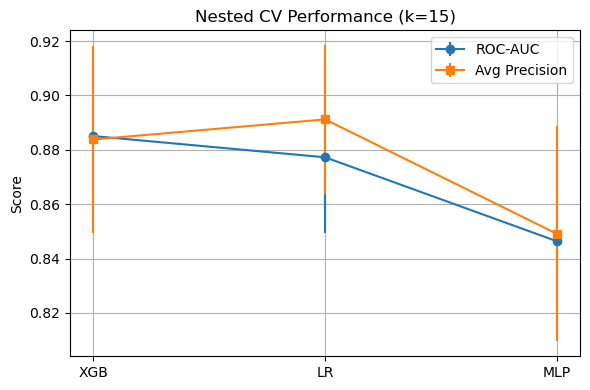

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.errorbar(df_results["model"], df_results["auc_mean"], 
             yerr=df_results["auc_std"], marker='o', label="ROC-AUC")

plt.errorbar(df_results["model"], df_results["ap_mean"], 
             yerr=df_results["ap_std"], marker='s', label="Avg Precision")

plt.ylabel("Score")
plt.title(f"Nested CV Performance (k={K})")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(ART_ROOT, "nested_cv_plot.png"), dpi=200)
plt.show()